Data Engineering module (Week 2) - Rationale: These libraries are required for Analytical and statistical analysis as well as EDA

In [3]:
import pandas as pd # Importing library to laod data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Data Engineering module (Week 2 and Week 3) Rationale: Loading the datasets and dropping unnecessary columns

In [4]:
crime_csv_url = '/content/MPS_Borough_Level_Crime_Analysis_Ready.csv'
pre_crime_df = pd.read_csv(crime_csv_url) # Loading the dataset
crime_df = pre_crime_df.drop(columns=['MajorText'], errors='ignore') # Drops MajorText from column without giving an error in case it isn't there
crime_df.head()

,Crime_Type,Borough,202401,202402,202403,202404,202405,202406,202407,202408,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,ARSON,Barking and Dagenham,4,5,6,3,8,2,3,10,...,4,12,10,10,11,10,5,6,8,7
1,CRIMINAL DAMAGE,Barking and Dagenham,126,124,134,112,102,106,131,114,...,103,124,108,124,137,126,100,100,106,126
2,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,31,21,30,24,28,33,21,26,...,24,20,27,25,24,23,23,16,22,23
3,RES BURGLARY OF A HOME,Barking and Dagenham,57,33,45,42,31,31,28,34,...,58,30,31,35,32,29,31,33,64,52
4,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,10,16,5,10,11,6,8,12,...,20,11,7,16,5,13,12,22,15,23


Data Engineering (Week 3) - Rationale: Check if datasets needs to be reshaped to make analysis more effective. In this case, reshaping is required

In [5]:
crime_df.info() # Checking column names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Crime_Type  1025 non-null   object
 1   Borough     1025 non-null   object
 2   202401      1025 non-null   int64 
 3   202402      1025 non-null   int64 
 4   202403      1025 non-null   int64 
 5   202404      1025 non-null   int64 
 6   202405      1025 non-null   int64 
 7   202406      1025 non-null   int64 
 8   202407      1025 non-null   int64 
 9   202408      1025 non-null   int64 
 10  202409      1025 non-null   int64 
 11  202410      1025 non-null   int64 
 12  202411      1025 non-null   int64 
 13  202412      1025 non-null   int64 
 14  202501      1025 non-null   int64 
 15  202502      1025 non-null   int64 
 16  202503      1025 non-null   int64 
 17  202504      1025 non-null   int64 
 18  202505      1025 non-null   int64 
 19  202506      1025 non-null   int64 
 20  202507  

Data Visualisation and Communication (Coursework) and corrected using ChatGPT AI - Rationale: Crime dataset needs to be reshaped into the long format for analysis to be carried out as data cannot be used in analysis if date format is on the X axis.

In [6]:
crime_df_long = crime_df.melt(
    id_vars=['Borough', 'Crime_Type'], # Columns to keep the same
    var_name='Month_Year', # Name for the variable column - Turns the month columns into 1 column called "Month_Year"
    value_name='Crime_Count' # Names for the values - Puts crime count into a new column named "Crime_Count"
)

In [7]:
crime_df_long.head()

,Borough,Crime_Type,Month_Year,Crime_Count
0,Barking and Dagenham,ARSON,202401,4
1,Barking and Dagenham,CRIMINAL DAMAGE,202401,126
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,202401,31
3,Barking and Dagenham,RES BURGLARY OF A HOME,202401,57
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,202401,10


Splitting Month and year so time-series plots are possible and merging (integration) with other datasets is possible

In [8]:
crime_df_long['Year'] = crime_df_long['Month_Year'].astype(str).str[:4] # Creating a new column "Year"
crime_df_long['Month'] = crime_df_long['Month_Year'].astype(str).str[4:] # Creating a new column called "Month"
crime_df_long = crime_df_long.drop(columns=['Month_Year']) # Dropping "Month_Year" after separating them
crime_df_long.head()

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01


Machine learning and Data Mining (Coursework) - Rationale: Missing value imputation so that there are no empty cells and analysis can be carried out without errors

In [9]:
crime_df_long['Crime_Count'] = crime_df_long['Crime_Count'].fillna(0) # Any months missing data becomes 0
crime_df_long.head(15)

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01
5,Barking and Dagenham,POSSESSION OF DRUGS,71,2024,01
6,Barking and Dagenham,TRAFFICKING OF DRUGS,29,2024,01
7,Barking and Dagenham,FRAUD AND FORGERY,0,2024,01
8,Barking and Dagenham,MISC CRIMES AGAINST SOCIETY,27,2024,01
9,Barking and Dagenham,POSSESSION OF WEAPONS,10,2024,01


Data Engineering (week 2)

In [10]:
crime_df_long.to_csv("Crime_Data_Jan2024_Dec2025.csv", index=False)

Data Engineering (Week 2)

In [11]:
processed_crime = '/content/Crime_Data_Jan2024_Dec2025.csv'
processed_crime = pd.read_csv(processed_crime)
processed_crime.head()

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,1
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,1
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,1
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,1
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,1


Data Engineering (Week 3) and modified with the help of AI assistant

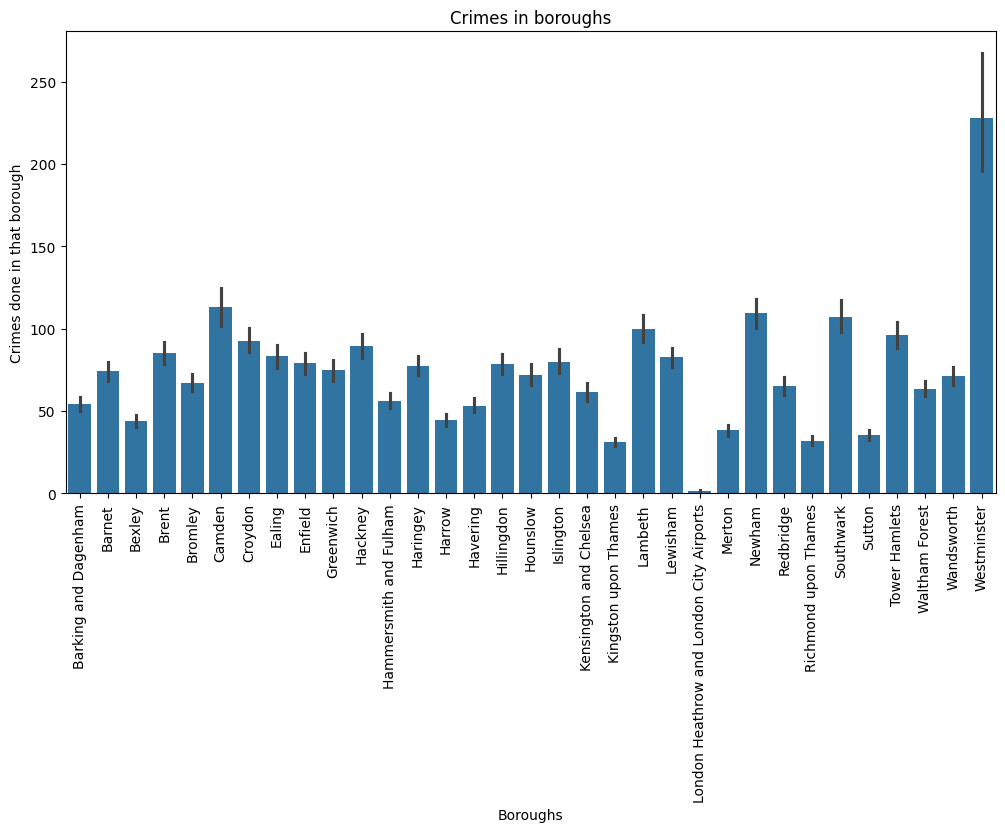

In [15]:
plt.figure(figsize= (12, 6))
sns.barplot(x=processed_crime['Borough'].values, y=processed_crime['Crime_Count'].values) # Setting the axes
plt.xticks(rotation=90)
plt.xlabel('Boroughs')
plt.ylabel('Crimes done in that borough')
plt.title('Crimes in boroughs')
plt.show()
# Aggregates the values together despite boroughs repeating multiple times in dataset